In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.integrate import solve_ivp
from scipy.stats import spearmanr
from functions import load_data, correlation

In [2]:
import os

# --- Style figures pour publication ---
# Largeur ~ 7" = double colonne ; export vectoriel PDF + PNG 300 dpi.
plt.rcParams.update({
    'figure.dpi'      : 120,        # rendu écran net
    'savefig.dpi'     : 300,        # export haute résolution
    'savefig.bbox'    : 'tight',
    'savefig.pad_inches': 0.02,
    'font.size'       : 9,
    'axes.titlesize'  : 10,
    'axes.labelsize'  : 9,
    'xtick.labelsize' : 8,
    'ytick.labelsize' : 8,
    'legend.fontsize' : 8,
    'axes.linewidth'  : 0.8,
    'lines.linewidth' : 1.2,
    'axes.formatter.use_mathtext': True,   # notation sci. rendue en ×10^n
    'figure.constrained_layout.use': False,
})

FIGDIR = 'results'
os.makedirs(FIGDIR, exist_ok=True)


def annotate_regimes(ax, periods, top_panel=False, headroom=0.18, fontsize=7):
    """Lignes pointillées aux transitions + labels de régime (en haut).

    Parameters
    ----------
    ax : Axes
        Panneau sur lequel tracer les transitions.
    periods : list of (Timestamp, Timestamp, str)
        Régimes (début, fin, label).
    top_panel : bool
        Si True, réserve une bande en haut de l'axe et y place les labels
        (via une transformation x=data, y=fraction d'axe), sans collision
        avec le titre.
    headroom : float
        Fraction de l'axe réservée en haut pour les labels (panneau du haut).
    fontsize : int
        Taille des labels de régime.
    """
    for s, _, _ in periods[1:]:
        ax.axvline(s, color='0.55', lw=0.8, ls='--', alpha=0.9, zorder=0)

    if top_panel:
        y0, y1 = ax.get_ylim()
        ax.set_ylim(y0, y1 + headroom * (y1 - y0))     # bande pour les labels
        for s, e, lab in periods:
            ax.text(s + (e - s) / 2, 0.99, lab,
                    transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=fontsize, color='0.25')


## 1. Identification des périodes

Trois diagnostiques calculés sur fenêtres glissantes pour repérer crises / régimes calmes :

- **max ρ_ij / ⟨ρ_ij⟩** — concentration des corrélations (off-diagonale).
- **λ_max / ⟨λ⟩** — dominance du mode de marché (Plerou et al., RMT).
- **⟨r⟩** — log-return moyen (across assets) lissé sur la fenêtre.

Pics simultanés sur (1)+(2) avec chute de (3) → période de crise.

In [3]:
data = load_data(['stock'], log_returns=True, sort_by_sector=True)
arr  = data.values
T, N = arr.shape
print(f'Actifs : {N}   |   Obs : {T}   |   Période : {data.index[0].date()} → {data.index[-1].date()}')

Actifs : 146   |   Obs : 13360   |   Période : 2019-04-01 → 2023-05-03


In [4]:
def rolling_diagnostics(data, window, step=None):
    """Rolling-window correlation diagnostics.

    Parameters
    ----------
    data : DataFrame, shape (T, N)
        Log-returns.
    window : int
        Window size in observations.
    step : int or None
        Step between windows. Defaults to window // 4.

    Returns
    -------
    DataFrame indexed by window-end date with columns
    'max_corr', 'mean_corr', 'ratio_corr',
    'max_eig', 'mean_eig', 'ratio_eig',
    'mean_return'.
    """
    if step is None:
        step = max(window // 4, 1)

    arr = data.values
    T, N = arr.shape
    iu = np.triu_indices(N, k=1)

    rows = []
    idx  = []
    for end in range(window, T + 1, step):
        start = end - window
        sub = arr[start:end]
        C = np.corrcoef(sub.T)
        off = np.abs(C[iu])
        eig = np.linalg.eigvalsh(C)

        rows.append({
            'max_corr'   : off.max(),
            'mean_corr'  : off.mean(),
            'ratio_corr' : off.max() / off.mean(),
            'max_eig'    : eig.max(),
            'mean_eig'   : eig.mean(),
            'ratio_eig'  : eig.max() / eig.mean(),
            'mean_return': sub.mean(),
        })
        idx.append(data.index[end - 1])

    return pd.DataFrame(rows, index=pd.DatetimeIndex(idx, name='date'))


# fenêtre ~ 1 mois de trading 30-min (≈ 13 obs/jour × 21 jours)
WINDOW = 13 * 21
STEP   = 13         # 1 point par jour

diag = rolling_diagnostics(data, window=WINDOW, step=STEP)
diag.head()

,max_corr,mean_corr,ratio_corr,max_eig,mean_eig,ratio_eig,mean_return
date,,,,,,,
2019-05-01 09:30:00,0.842195,0.147051,5.727215,17.609273,1.0,17.609273,0.000078
2019-05-02 09:30:00,0.840365,0.148468,5.660243,18.094847,1.0,18.094847,0.000043
2019-05-03 09:30:00,0.842799,0.151076,5.578645,18.929166,1.0,18.929166,0.000052
2019-05-06 09:30:00,0.856568,0.168673,5.078277,23.682026,1.0,23.682026,0.000026
2019-05-07 09:30:00,0.859637,0.184403,4.661733,27.040233,1.0,27.040233,0.000001


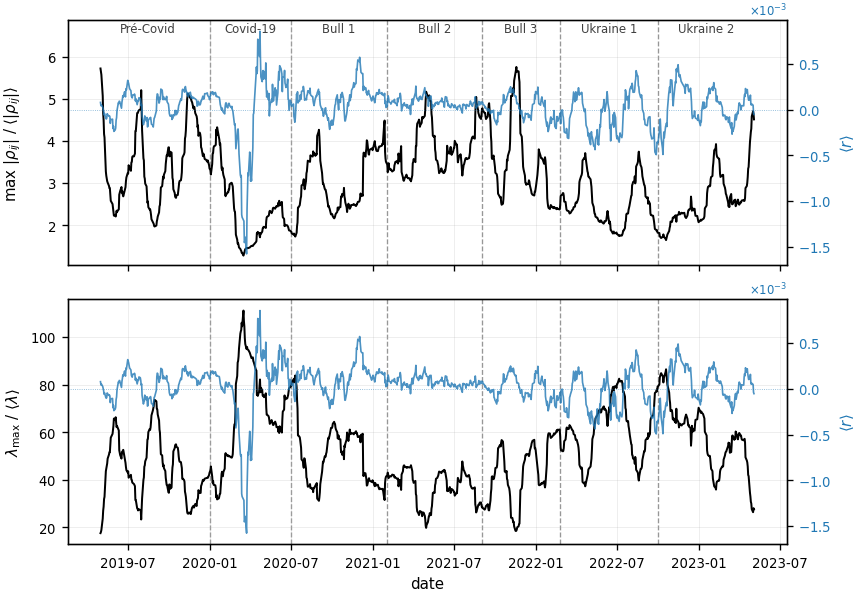

In [5]:
# Régimes de marché (start, end, label)
events = [
    ('2019-04-01', '2019-12-31', 'Pré-Covid'),
    ('2020-01-01', '2020-06-30', 'Covid-19'),
    ('2020-07-01', '2021-01-31', 'Bull 1'),
    ('2021-02-01', '2021-08-31', 'Bull 2'),
    ('2021-09-01', '2022-02-23', 'Bull 3'),
    ('2022-02-24', '2022-09-30', 'Ukraine 1'),
    ('2022-10-01', '2023-05-03', 'Ukraine 2'),
]
events = [(pd.Timestamp(s), pd.Timestamp(e), lab) for s, e, lab in events]

# métriques réseau (noir) ; le log-return moyen (bleu) est superposé sur chacune
metrics = [
    ('ratio_corr', r'max $|\rho_{ij}|$ / $\langle |\rho_{ij}|\rangle$'),
    ('ratio_eig',  r'$\lambda_{\max}$ / $\langle\lambda\rangle$'),
]

fig, axes = plt.subplots(len(metrics), 1, figsize=(7.2, 5.0),
                         sharex=True, layout='constrained')

for ax, (key, label) in zip(axes, metrics):
    # métrique réseau (noir)
    ax.plot(diag.index, diag[key], color='black')
    ax.set_ylabel(label)
    ax.grid(alpha=0.25, lw=0.5)
    ax.margins(x=0.01)

    # log-return moyen (bleu) superposé, axe jumeau (échelle propre)
    axb = ax.twinx()
    axb.plot(diag.index, diag['mean_return'], color='tab:blue', lw=1.0, alpha=0.8)
    axb.axhline(0, color='tab:blue', lw=0.5, ls=':', alpha=0.6)
    axb.set_ylabel(r'$\langle r\rangle$', color='tab:blue')
    axb.tick_params(axis='y', labelcolor='tab:blue')
    # écriture scientifique sur l'axe log-return (facteur ×10^n en haut)
    axb.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axb.yaxis.get_offset_text().set_color('tab:blue')
    axb.yaxis.get_offset_text().set_size(7)

    annotate_regimes(ax, events, top_panel=(ax is axes[0]))

axes[-1].set_xlabel('date')
fig.align_ylabels(axes)   # aligne horizontalement les labels Y (gauche)

fig.savefig(f'{FIGDIR}/fig_periodes.pdf')
fig.savefig(f'{FIGDIR}/fig_periodes.png')
plt.show()

## 2. Évolution globale du réseau et des rendements (méthode Achitouv 2025)

Reproduction de la démarche d'Achitouv (PLoS One 2025, *Dynamical analysis of financial stocks network*), Fig. 4 « temps court », sur nos données (146 actions, barres 30 min, 2019–2023).

**Construction du réseau** (par intervalle, à la Achitouv) :
1. On découpe la série en **intervalles non recouvrants de 2 jours ouvrés** (`SHORT = 26` obs) → `Nobs` mesures (une tous les 2 jours).
2. Sur chaque intervalle, matrice de corrélation des log-returns (éq. 9).
3. **Threshold method** : `A_ij = C_ij` si `|C_ij| ≥ ρc`, sinon 0 — réseau **pondéré** (on garde les poids `|C_ij|`).
4. **Seuil scale-free** : `ρc` = plus petite valeur (départ 0.8, pas 0.1) pour laquelle la **distribution des degrés devient convexe** (loi de puissance) → `ρc ≈ 0.9`.

**Propriétés globales mesurées** (courbes noires) : 90ᵉ percentile du degré, closeness/betweenness/eigenvector moyennes, clustering pondéré moyen, plus grande composante, résilience, stabilité des communautés (modularité), et plus grande valeur propre de la matrice de corrélation.

**Courbe bleue** : rendement global moyen (moyenne non pondérée des returns), rescalé. Tout est lissé par une **moyenne glissante W = 23**, comme dans le papier.

In [6]:
import warnings


def degree_dist_convex(deg, qcap=0.9):
    """Distribution des degrés convexe (proxy scale-free / loi de puissance).

    Convexité testée sur la plage des degrés faibles (jusqu'au quantile
    ``qcap``) via la différence seconde >= 0 du comptage par degré.

    Parameters
    ----------
    deg : ndarray
        Séquence des degrés des noeuds.
    qcap : float
        Quantile de degré bornant la plage testée (ignore la queue éparse).
    """
    counts = np.bincount(deg, minlength=int(deg.max()) + 1).astype(float)
    kmax = int(np.quantile(deg, qcap))
    return True if kmax < 2 else np.all(np.diff(counts[:kmax + 1], 2) >= 0)


def scale_free_threshold(C, start=0.8, step=0.1, cap=0.95):
    """Seuil ``rho_c`` minimal rendant la distribution des degrés convexe.

    Boucle d'Achitouv : démarre à ``start``, incrémente de ``step`` tant que
    la distribution des degrés du graphe seuillé n'est pas convexe.

    Parameters
    ----------
    C : ndarray (N, N)
        Matrice de corrélation.
    start, step, cap : float
        Valeur initiale, incrément et plafond du seuil.
    """
    rc = start
    while rc <= cap:
        A = (np.abs(C) >= rc).astype(int)
        np.fill_diagonal(A, 0)
        if degree_dist_convex(A.sum(1)):
            return rc
        rc = round(rc + step, 2)
    return cap


def eigenvector_centrality_mean(Wt):
    """Centralité de vecteur propre = vecteur propre principal de l'adjacence.

    Robuste aux graphes déconnectés (contrairement à
    ``nx.eigenvector_centrality_numpy``) : on prend directement le vecteur
    propre de plus grande valeur propre de la matrice d'adjacence pondérée.

    Parameters
    ----------
    Wt : ndarray (N, N)
        Matrice d'adjacence pondérée (symétrique).
    """
    try:
        _, vecs = np.linalg.eigh(Wt)
    except np.linalg.LinAlgError:                      # repli si non-convergence
        vals, vecs = np.linalg.eig(Wt)
        vecs = vecs[:, np.argsort(vals.real)].real
    v = np.abs(vecs[:, -1])
    n = np.linalg.norm(v)
    return (v / n).mean() if n > 0 else 0.0


def network_resilience(Gb, frac=0.1, n_total=None):
    """Résilience R = taille de la plus grande composante après attaque ciblée.

    On retire les ``frac`` noeuds de plus haut degré puis on mesure la
    fraction de noeuds dans la plus grande composante restante.

    Parameters
    ----------
    Gb : networkx.Graph
        Graphe binaire.
    frac : float
        Fraction de noeuds (les plus connectés) retirés.
    n_total : int or None
        Nombre de noeuds de référence (défaut : ordre de ``Gb``).
    """
    n_total = n_total or Gb.number_of_nodes()
    G2 = Gb.copy()
    hubs = [n for n, _ in sorted(G2.degree(), key=lambda x: -x[1])[:int(frac * n_total)]]
    G2.remove_nodes_from(hubs)
    if G2.number_of_nodes() == 0:
        return 0.0
    return max((len(c) for c in nx.connected_components(G2)), default=0) / n_total


def global_network_properties(C, n_assets):
    """Propriétés globales du réseau seuillé (méthode Achitouv) pour une matrice C."""
    rc = scale_free_threshold(C)
    Wt = np.abs(C) * (np.abs(C) >= rc)            # adjacence pondérée (poids = |C|)
    np.fill_diagonal(Wt, 0.0)
    G = nx.from_numpy_array(Wt)                    # graphe pondéré
    Gb = nx.from_numpy_array((Wt > 0).astype(int))  # graphe binaire (chemins)
    deg = np.array([d for _, d in Gb.degree()])
    comm = nx.community.greedy_modularity_communities(Gb)

    return {
        'rho_c'              : rc,
        'p90_degree'         : np.percentile(deg, 90),
        'mean_closeness'     : np.mean(list(nx.closeness_centrality(Gb).values())),
        'mean_betweenness'   : np.mean(list(nx.betweenness_centrality(Gb).values())),
        'mean_eigenvector'   : eigenvector_centrality_mean(Wt),
        'mean_clustering'    : nx.average_clustering(G, weight='weight'),
        'largest_component'  : max((len(c) for c in nx.connected_components(Gb)), default=0) / n_assets,
        'resilience'         : network_resilience(Gb, frac=0.1, n_total=n_assets),
        'community_stability': nx.community.modularity(Gb, comm) if Gb.number_of_edges() else 0.0,
        'max_eigenvalue'     : np.linalg.eigvalsh(C).max(),
    }


# --- Calcul sur intervalles non recouvrants de 2 jours ouvrés ---
SHORT = 2 * 13          # 2 jours ouvrés = 26 obs (13 obs/jour)
W     = 23              # fenêtre de lissage (rolling mean), comme Achitouv
n_int = T // SHORT

rows, dates, mean_ret = [], [], []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for i in range(n_int):
        sub = arr[i * SHORT:(i + 1) * SHORT]
        C = np.nan_to_num(np.corrcoef(sub.T))
        rows.append(global_network_properties(C, N))
        mean_ret.append(sub.mean())                 # rendement global moyen
        dates.append(data.index[(i + 1) * SHORT - 1])

netg = pd.DataFrame(rows, index=pd.DatetimeIndex(dates, name='date'))
netg['mean_return'] = mean_ret
netg_s = netg.rolling(W, center=True, min_periods=1).mean()   # lissage W = 23

print(f'Nobs (mesures tous les 2 jours) = {len(netg)}   |   ρc médian = {netg["rho_c"].median()}')
netg.drop(columns='rho_c').describe().round(3).T[['mean', 'min', 'max']]

Nobs (mesures tous les 2 jours) = 513   |   ρc médian = 0.9


,mean,min,max
p90_degree,1.804,0.000,31.000
mean_closeness,0.008,0.000,0.141
mean_betweenness,0.000,0.000,0.009
mean_eigenvector,0.019,0.007,0.045
mean_clustering,0.051,0.000,0.294
largest_component,0.101,0.007,0.692
resilience,0.024,0.007,0.534
community_stability,0.619,0.000,0.883
max_eigenvalue,61.084,28.387,121.195
mean_return,0.000,-0.004,0.004


## 3. Visualisation du réseau de corrélations

Réseau seuillé sur une période donnée, **selon la méthode d'Achitouv** : un lien
relie deux actifs dès que `|ρ_ij| ≥ ρ_c`, et le seuil `ρ_c` est fixé par le
**critère scale-free** (`scale_free_threshold`, section 2 : plus petite valeur
rendant la distribution des degrés convexe).

Le mode de seuillage de toute la section 3 est piloté par l'interrupteur
**`USE_SCALE_FREE`** (cellule suivante) : `True` = scale-free d'Achitouv (défaut),
`False` = quantile « top (1 − `TOPQ`) % » des |ρ| (réseaux plus denses/lisibles).

Disposition **ForceAtlas2** (`nx.forceatlas2_layout`, comme Achitouv/Gephi ;
graine `seed` = `r=` dans le titre), nœuds **colorés par secteur** et
dimensionnés selon leur degré ; on affiche **toutes les composantes non isolées**
(`giant_only=False`).

> **Remarque données.** La recherche scale-free démarre ici à `SF_START = 0.5`
> (pas `SF_STEP = 0.01`) et non à 0.8 comme Achitouv : sur nos barres 30 min les
> corrélations intraday sont plus faibles, et démarrer à 0.8 renvoyait le
> plancher pour toutes les périodes. Avec 0.5, le seuil retenu **varie selon le
> régime** et les réseaux restent épars (plusieurs petites composantes).

Mode : scale-free threshold (Achitouv)   |   Nœuds : 56   |   Liens : 72


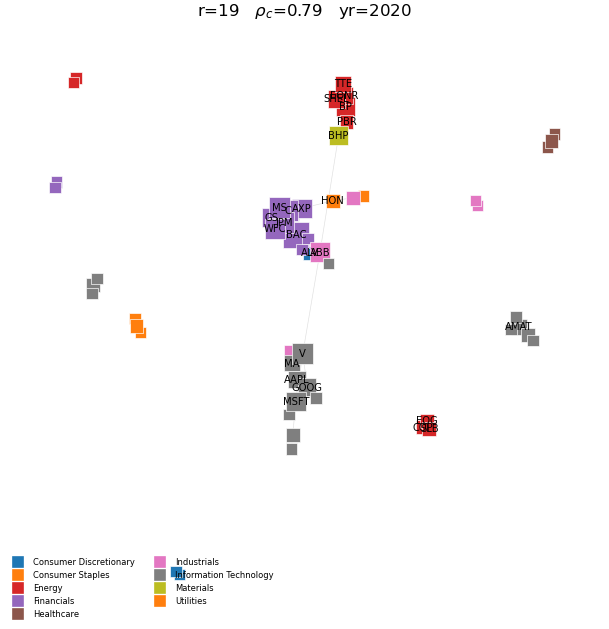

In [7]:
# secteurs (mêmes que pour l'ordre des colonnes)
sectors = pd.read_excel('data/stock_category.xlsx').set_index('Stocks')['Sectors']

# palette secteur partagée : couleurs stables d'une période à l'autre
SECTOR_COLORS = {s: plt.get_cmap('tab10')(k % 10)
                 for k, s in enumerate(sorted(sectors.dropna().unique()))}

# régimes de marché (mêmes bornes qu'en section 1)
periods = [
    ('2019-04-01', '2019-12-31', 'Pre-Covid'),
    ('2020-01-01', '2020-06-30', 'Covid-19'),
    ('2020-07-01', '2021-01-31', 'Bull 1'),
    ('2021-02-01', '2021-08-31', 'Bull 2'),
    ('2021-09-01', '2022-02-23', 'Bull 3'),
    ('2022-02-24', '2022-09-30', 'Ukraine 1'),
    ('2022-10-01', '2023-05-03', 'Ukraine 2'),
]
periods = [(pd.Timestamp(s), pd.Timestamp(e), lab) for s, e, lab in periods]

# --- Choix du seuil rho_c pour TOUTE la section 3 ---
# USE_SCALE_FREE = True  -> seuil scale-free d'Achitouv (scale_free_threshold)
# USE_SCALE_FREE = False -> quantile « top (1 - TOPQ) % » des |rho|
USE_SCALE_FREE = True
SF_START = 0.5     # départ de la recherche scale-free (0.8 chez Achitouv ;
SF_STEP = 0.01     # 0.5 ici car les |rho| intraday sont plus faibles)
TOPQ = 0.97
THRESH_LABEL = ('scale-free threshold (Achitouv)' if USE_SCALE_FREE
                else f'top {100 * (1 - TOPQ):.0f}% of |ρ|')


def choose_rho_c(C, top_quantile=TOPQ):
    """Seuil rho_c selon le mode global (Achitouv scale-free ou quantile).

    Parameters
    ----------
    C : ndarray (N, N)
        Matrice de corrélation, diagonale déjà mise à 0.
    top_quantile : float
        Quantile utilisé en mode non scale-free.
    """
    if USE_SCALE_FREE:
        return scale_free_threshold(C, start=SF_START, step=SF_STEP)
    iu = np.triu_indices(C.shape[0], 1)
    return float(np.quantile(np.abs(C[iu]), top_quantile))


def n_communities(G, seed=19):
    """Nombre de communautés Louvain du graphe (0 si vide)."""
    if G.number_of_nodes() == 0:
        return 0
    return len(nx.community.louvain_communities(G, weight='weight', seed=seed))


def sf_rho_c(data, period=None, start=SF_START, step=SF_STEP, cap=0.98):
    """Seuil scale-free d'Achitouv (``scale_free_threshold``) sur une période.

    Parameters
    ----------
    data : DataFrame, shape (T, N)
        Log-returns, actifs en colonnes.
    period : (start, end) or None
        Tranche de dates ; None = tout l'échantillon.
    start, step, cap : float
        Paramètres de la recherche du seuil (cf. ``scale_free_threshold``).
    """
    sub = data.loc[period[0]:period[1]] if period else data
    C = np.corrcoef(sub.values.T)
    np.fill_diagonal(C, 0.0)
    return scale_free_threshold(C, start=start, step=step, cap=cap)


def correlation_network(data, sectors, period=None, rho_c=None, top_quantile=TOPQ,
                        seed=19, label_top=25, giant_only=False, ax=None,
                        title=None, prefix='', legend=True):
    """Réseau de corrélations seuillé, ForceAtlas2, coloré par secteur.

    Parameters
    ----------
    data : DataFrame, shape (T, N)
        Log-returns, actifs en colonnes.
    sectors : Series
        Correspondance {actif: secteur}.
    period : (start, end) or None
        Tranche de dates utilisée pour la corrélation. None = tout l'échantillon.
    rho_c : float or None
        Seuil ; lien tracé si |rho_ij| >= rho_c. Si None, déterminé par
        ``choose_rho_c`` (scale-free Achitouv ou quantile selon le mode global).
    top_quantile : float
        Quantile transmis à ``choose_rho_c`` en mode non scale-free.
    seed : int
        Graine du layout ForceAtlas2 (affichée ``r=`` dans le titre).
    label_top : int
        Nombre de nœuds de plus haut degré annotés de leur ticker.
    giant_only : bool
        Ne garder que la plus grande composante connexe ; False = toutes les
        composantes non isolées (recommandé pour les réseaux épars du mode
        scale-free).
    ax : Axes or None
        Axe cible ; créé si None.
    title : str or None
        Titre. None = titre par défaut ``prefix + r= rho_c= yr=`` ;
        chaîne vide '' = aucun titre.
    prefix : str
        Préfixe ajouté au titre par défaut (ex. libellé de régime).
    legend : bool
        Afficher la légende des secteurs (à désactiver en mosaïque).
    """
    sub = data.loc[period[0]:period[1]] if period else data
    assets = data.columns.tolist()
    C = np.corrcoef(sub.values.T)
    np.fill_diagonal(C, 0.0)

    if rho_c is None:
        rho_c = choose_rho_c(C, top_quantile)

    G = nx.Graph()
    G.add_nodes_from(range(len(assets)))
    for i, j in zip(*np.where(np.triu(np.abs(C) >= rho_c, 1))):
        G.add_edge(i, j, weight=abs(C[i, j]))

    G.remove_nodes_from(list(nx.isolates(G)))
    if giant_only and G.number_of_nodes():
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    secs = sectors.reindex(assets).fillna('Other')
    node_colors = [SECTOR_COLORS.get(secs[assets[i]], '0.6') for i in G.nodes]

    deg = dict(G.degree())
    node_sizes = [25 + 22 * deg[i] for i in G.nodes]

    # disposition ForceAtlas2 (comme Achitouv/Gephi), pondérée par |rho|
    if G.number_of_nodes():
        pos = nx.forceatlas2_layout(G, seed=seed, weight='weight')
    else:
        pos = {}

    if ax is None:
        _, ax = plt.subplots(figsize=(6.5, 6.5))
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='0.6', width=0.4, alpha=0.3)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=node_sizes, node_shape='s',
                           edgecolors='white', linewidths=0.4)

    order = sorted(deg, key=deg.get, reverse=True)[:label_top]
    nx.draw_networkx_labels(G, pos, labels={i: assets[i] for i in order},
                            ax=ax, font_size=6)

    yr = sub.index[0].year
    default_title = (prefix + f"r={seed}   " + r"$\rho_c$" + f"={rho_c:.2f}   yr={yr}")
    ax.set_title(default_title if title is None else title, fontsize=10)
    ax.axis('off')
    if legend:
        uniq = sorted(secs.loc[[assets[i] for i in G.nodes]].unique())
        handles = [plt.Line2D([0], [0], marker='s', ls='', color=SECTOR_COLORS[s],
                              label=s, markersize=6) for s in uniq]
        ax.legend(handles=handles, fontsize=5, loc='lower left',
                  frameon=False, ncol=2)
    return G, ax


# Réseau Covid-19 (2020) — seuil selon le mode global (Achitouv par défaut)
PERIOD_DEMO = ('2020-01-01', '2020-06-30')

fig, ax = plt.subplots(figsize=(6.5, 6.5))
G, _ = correlation_network(data, sectors, period=PERIOD_DEMO, seed=19, ax=ax)
print(f'Mode : {THRESH_LABEL}   |   Nœuds : {G.number_of_nodes()}   '
      f'|   Liens : {G.number_of_edges()}')

fig.savefig(f'{FIGDIR}/fig_correlation_network.pdf')
fig.savefig(f'{FIGDIR}/fig_correlation_network.png')
plt.show()

### 3.1 Distributions du réseau

Pour le même réseau seuillé (`|ρ_ij| ≥ ρ_c`), deux distributions sur les nœuds
de la composante non isolée :

- **degrés** — nombre de voisins par nœud, en échelle log (une queue de hubs
  apparaît à droite) ;
- **coefficient de clustering local** — propension des voisins d'un nœud à être
  eux-mêmes connectés ; la ligne pointillée rouge marque la moyenne.

Nœuds : 56   |   clustering moyen : 0.317


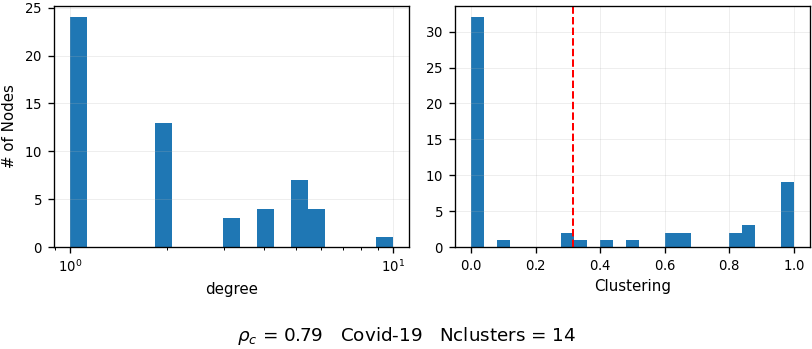

In [8]:
def network_distributions(data, period=None, rho_c=None, top_quantile=TOPQ,
                          n_bins=25, axes=None, title=None, prefix='',
                          period_label=None, suptitle=True):
    """Distributions des degrés (log) et du clustering pour le réseau seuillé.

    Parameters
    ----------
    data : DataFrame, shape (T, N)
        Log-returns, actifs en colonnes.
    period : (start, end) or None
        Tranche de dates pour la corrélation. None = tout l'échantillon.
    rho_c : float or None
        Seuil ; lien si |rho_ij| >= rho_c. Si None, déterminé par
        ``choose_rho_c`` (scale-free Achitouv ou quantile selon le mode global).
    top_quantile : float
        Quantile transmis à ``choose_rho_c`` en mode non scale-free.
    n_bins : int
        Nombre de classes de l'histogramme de clustering.
    axes : (Axes, Axes) or None
        Couple d'axes (degré, clustering) ; créés si None.
    title : str or None
        Titre complet ; sinon construit à partir de rho_c, période et Nclusters.
    prefix : str
        Préfixe ajouté au titre (ex. libellé de régime).
    period_label : str or None
        Nom de la période affiché à la place de ``yr=`` (ex. 'Covid-19').
    suptitle : bool
        Si True, titre en bas de figure (suptitle) ; sinon titre sur l'axe
        de gauche (utile en mosaïque, une ligne par période).
    """
    sub = data.loc[period[0]:period[1]] if period else data
    assets = data.columns.tolist()
    C = np.corrcoef(sub.values.T)
    np.fill_diagonal(C, 0.0)
    if rho_c is None:
        rho_c = choose_rho_c(C, top_quantile)

    G = nx.from_numpy_array((np.abs(C) >= rho_c).astype(int))
    G.remove_nodes_from(list(nx.isolates(G)))
    deg = np.array([d for _, d in G.degree()])
    clus = np.array(list(nx.clustering(G).values()))

    if axes is None:
        _, axes = plt.subplots(1, 2, figsize=(7, 3.2))
    ax1, ax2 = axes

    # degrés (échelle log)
    bins = np.logspace(0, np.log10(max(deg.max(), 2)), 20)
    ax1.hist(deg, bins=bins, color='tab:blue')
    ax1.set_xscale('log')
    ax1.set_xlabel('degree')
    ax1.set_ylabel('# of Nodes')
    ax1.grid(alpha=0.25, lw=0.5)

    # clustering + moyenne
    ax2.hist(clus, bins=n_bins, color='tab:blue')
    ax2.axvline(clus.mean(), color='red', ls='--', lw=1.2)
    ax2.set_xlabel('Clustering')
    ax2.grid(alpha=0.25, lw=0.5)

    # titre : rho_c, nom de période (au lieu de yr), nombre de communautés Louvain
    when = period_label if period_label is not None else f"yr={sub.index[0].year}"
    ncomm = n_communities(G)
    txt = title or (prefix + r"$\rho_c$" + f" = {rho_c:.2f}   {when}   "
                    f"Nclusters = {ncomm}")
    if suptitle:
        ax1.figure.suptitle(txt, y=0.02, fontsize=11)
    else:
        ax1.set_title(txt, fontsize=9, loc='left')
    return G


# Distributions Covid-19 (2020), même seuil que la fig. réseau
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
G = network_distributions(data, period=PERIOD_DEMO, period_label='Covid-19', axes=axes)
fig.tight_layout(rect=[0, 0.05, 1, 1])
print(f'Nœuds : {G.number_of_nodes()}   |   clustering moyen : '
      f'{nx.average_clustering(G):.3f}')

fig.savefig(f'{FIGDIR}/fig_network_distributions.pdf')
fig.savefig(f'{FIGDIR}/fig_network_distributions.png')
plt.show()

### 3.1bis Degré vs rang (Zipf)

Diagramme rang-degré : pour chaque période, on classe les nœuds par degré
décroissant et on trace le degré en fonction du rang, en **log-log**. Une
droite (décroissance en loi de puissance) signale une organisation
scale-free / la présence de hubs ; un plateau suivi d'une chute brutale
indique au contraire une queue de degrés homogène. Une courbe par régime.

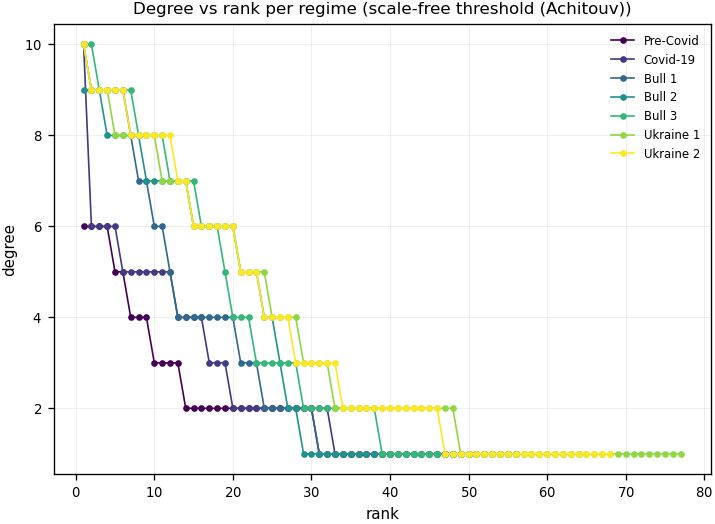

In [9]:
def degree_rank(data, period=None, rho_c=None, top_quantile=TOPQ, ax=None,
                color=None, label=None, marker='o'):
    """Courbe rang-degré (log-log) du réseau seuillé sur une période.

    Les nœuds sont classés par degré décroissant : on trace le degré en
    ordonnée contre le rang (1 = nœud le plus connecté) en abscisse.

    Parameters
    ----------
    data : DataFrame, shape (T, N)
        Log-returns, actifs en colonnes.
    period : (start, end) or None
        Tranche de dates pour la corrélation. None = tout l'échantillon.
    rho_c : float or None
        Seuil ; lien si |rho_ij| >= rho_c. Si None, déterminé par
        ``choose_rho_c`` (scale-free Achitouv ou quantile selon le mode global).
    top_quantile : float
        Quantile transmis à ``choose_rho_c`` en mode non scale-free.
    ax : Axes or None
        Axe cible ; créé si None.
    color, label, marker :
        Style de la courbe (couleur, libellé de légende, marqueur).

    Returns
    -------
    deg : ndarray
        Degrés triés par ordre décroissant (nœuds non isolés).
    """
    sub = data.loc[period[0]:period[1]] if period else data
    C = np.corrcoef(sub.values.T)
    np.fill_diagonal(C, 0.0)
    if rho_c is None:
        rho_c = choose_rho_c(C, top_quantile)

    G = nx.from_numpy_array((np.abs(C) >= rho_c).astype(int))
    G.remove_nodes_from(list(nx.isolates(G)))
    deg = np.sort([d for _, d in G.degree()])[::-1]
    rank = np.arange(1, len(deg) + 1)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4.5))
    ax.plot(rank, deg, marker=marker, ms=3, lw=1.0, color=color, label=label)
    ax.set_xlabel('rank')
    ax.set_ylabel('degree')
    ax.grid(alpha=0.25, lw=0.5, which='both')
    return deg


# Une courbe rang-degré par régime (même mode de seuil que les réseaux)
fig, ax = plt.subplots(figsize=(6.2, 4.6))
cmap = plt.get_cmap('viridis')

for k, (start, end, label) in enumerate(periods):
    degree_rank(data, period=(start, end), ax=ax,
                color=cmap(k / (len(periods) - 1)), label=label)

ax.set_title(f'Degree vs rank per regime ({THRESH_LABEL})')
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_degree_rank.pdf')
fig.savefig(f'{FIGDIR}/fig_degree_rank.png')
plt.show()

### 3.2 Mosaïque par régime de marché

Les sept régimes définis en section 1 (Pré-Covid, Covid-19, Bull 1-3,
Ukraine 1-2), chacun avec son seuil `ρ_c` selon le mode global
(`USE_SCALE_FREE`). Deux planches : les **réseaux** (une vignette par régime)
puis les **distributions** degrés / clustering (une ligne par régime).

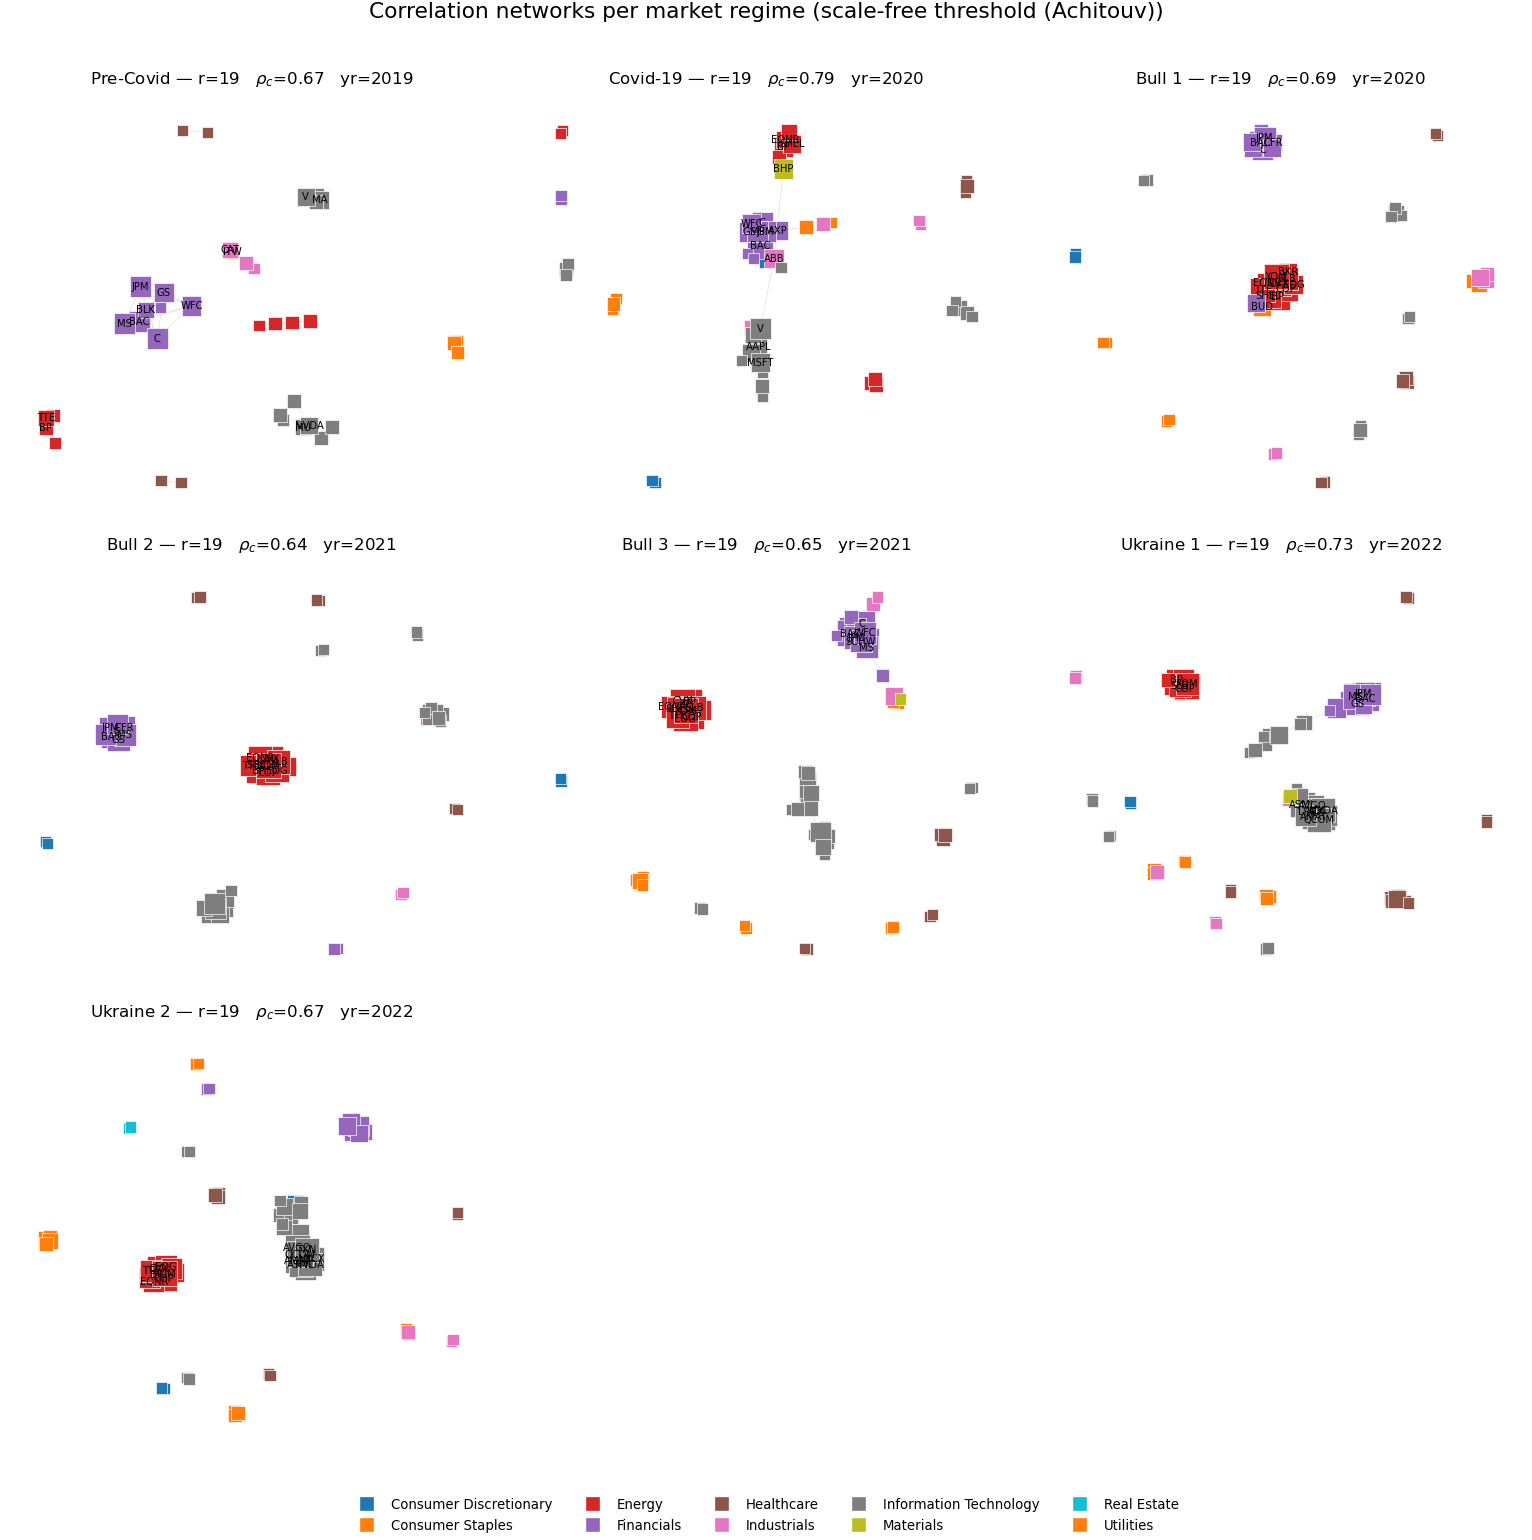

In [10]:
# --- Mosaïque des réseaux : une vignette par régime (mode de seuil global) ---
ncol = 3
nrow = int(np.ceil(len(periods) / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(13, 4.2 * nrow))
axes = axes.ravel()

for ax, (start, end, label) in zip(axes, periods):
    correlation_network(data, sectors, period=(start, end),
                        seed=19, label_top=15, ax=ax, prefix=f"{label} — ",
                        legend=False)
for ax in axes[len(periods):]:          # masquer les cases vides
    ax.axis('off')

# légende unique des secteurs présents, partagée
present = sorted(sectors.reindex(data.columns).dropna().unique())
handles = [plt.Line2D([0], [0], marker='s', ls='', color=SECTOR_COLORS[s],
                      label=s, markersize=7) for s in present]
fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False,
           fontsize=8, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(f'Correlation networks per market regime ({THRESH_LABEL})',
             fontsize=13, y=1.0)
fig.tight_layout(rect=[0, 0.03, 1, 0.99])
fig.savefig(f'{FIGDIR}/fig_network_mosaic.pdf')
fig.savefig(f'{FIGDIR}/fig_network_mosaic.png')
plt.show()

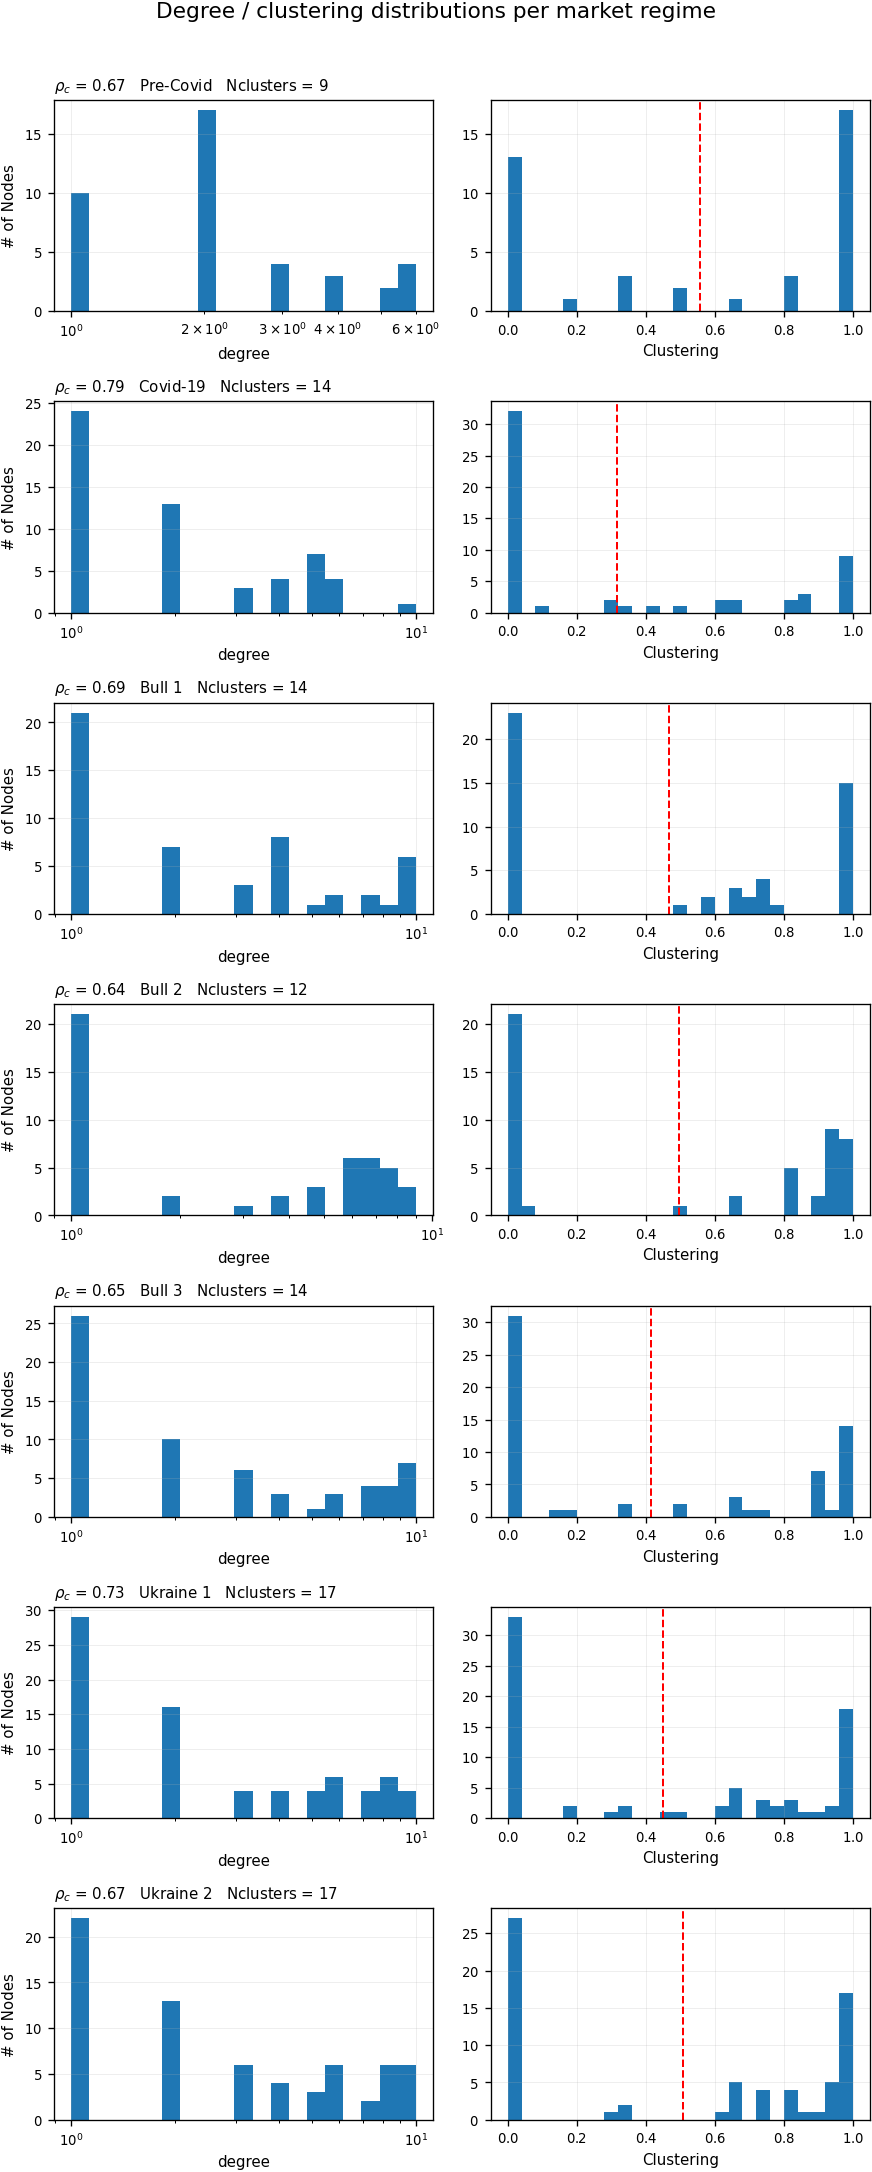

In [11]:
# --- Mosaïque des distributions : une ligne (degré, clustering) par régime ---
fig, axes = plt.subplots(len(periods), 2, figsize=(7.5, 2.6 * len(periods)))

for row, (start, end, label) in zip(axes, periods):
    network_distributions(data, period=(start, end), axes=row,
                          period_label=label, suptitle=False)

fig.suptitle('Degree / clustering distributions per market regime',
             fontsize=13, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(f'{FIGDIR}/fig_distributions_mosaic.pdf')
fig.savefig(f'{FIGDIR}/fig_distributions_mosaic.png')
plt.show()

### 3.3 Planche composite par régime

Un panneau par régime ; dans chaque panneau le **réseau** (ForceAtlas2, coloré
par secteur) occupe la moitié haute, et en bas trois diagnostics : **degree vs
rank**, **# of nodes vs degree** (échelle log) et **clustering** (moyenne en
pointillé rouge). Sous-titre = `ρ_c`, nom de période, `Nclusters` (communautés
Louvain).

Pour l'impression, la planche est **scindée en deux figures** (`composite_board`
appelé deux fois) afin que tout tienne sur une page sans rapetisser :
- `fig_composite_mosaic_1` : 6 premiers régimes (3 × 2) ;
- `fig_composite_mosaic_2` : dernier régime + légende des secteurs.

En LaTeX, enchaîner les deux avec `\ContinuedFloat` (même numéro de figure).

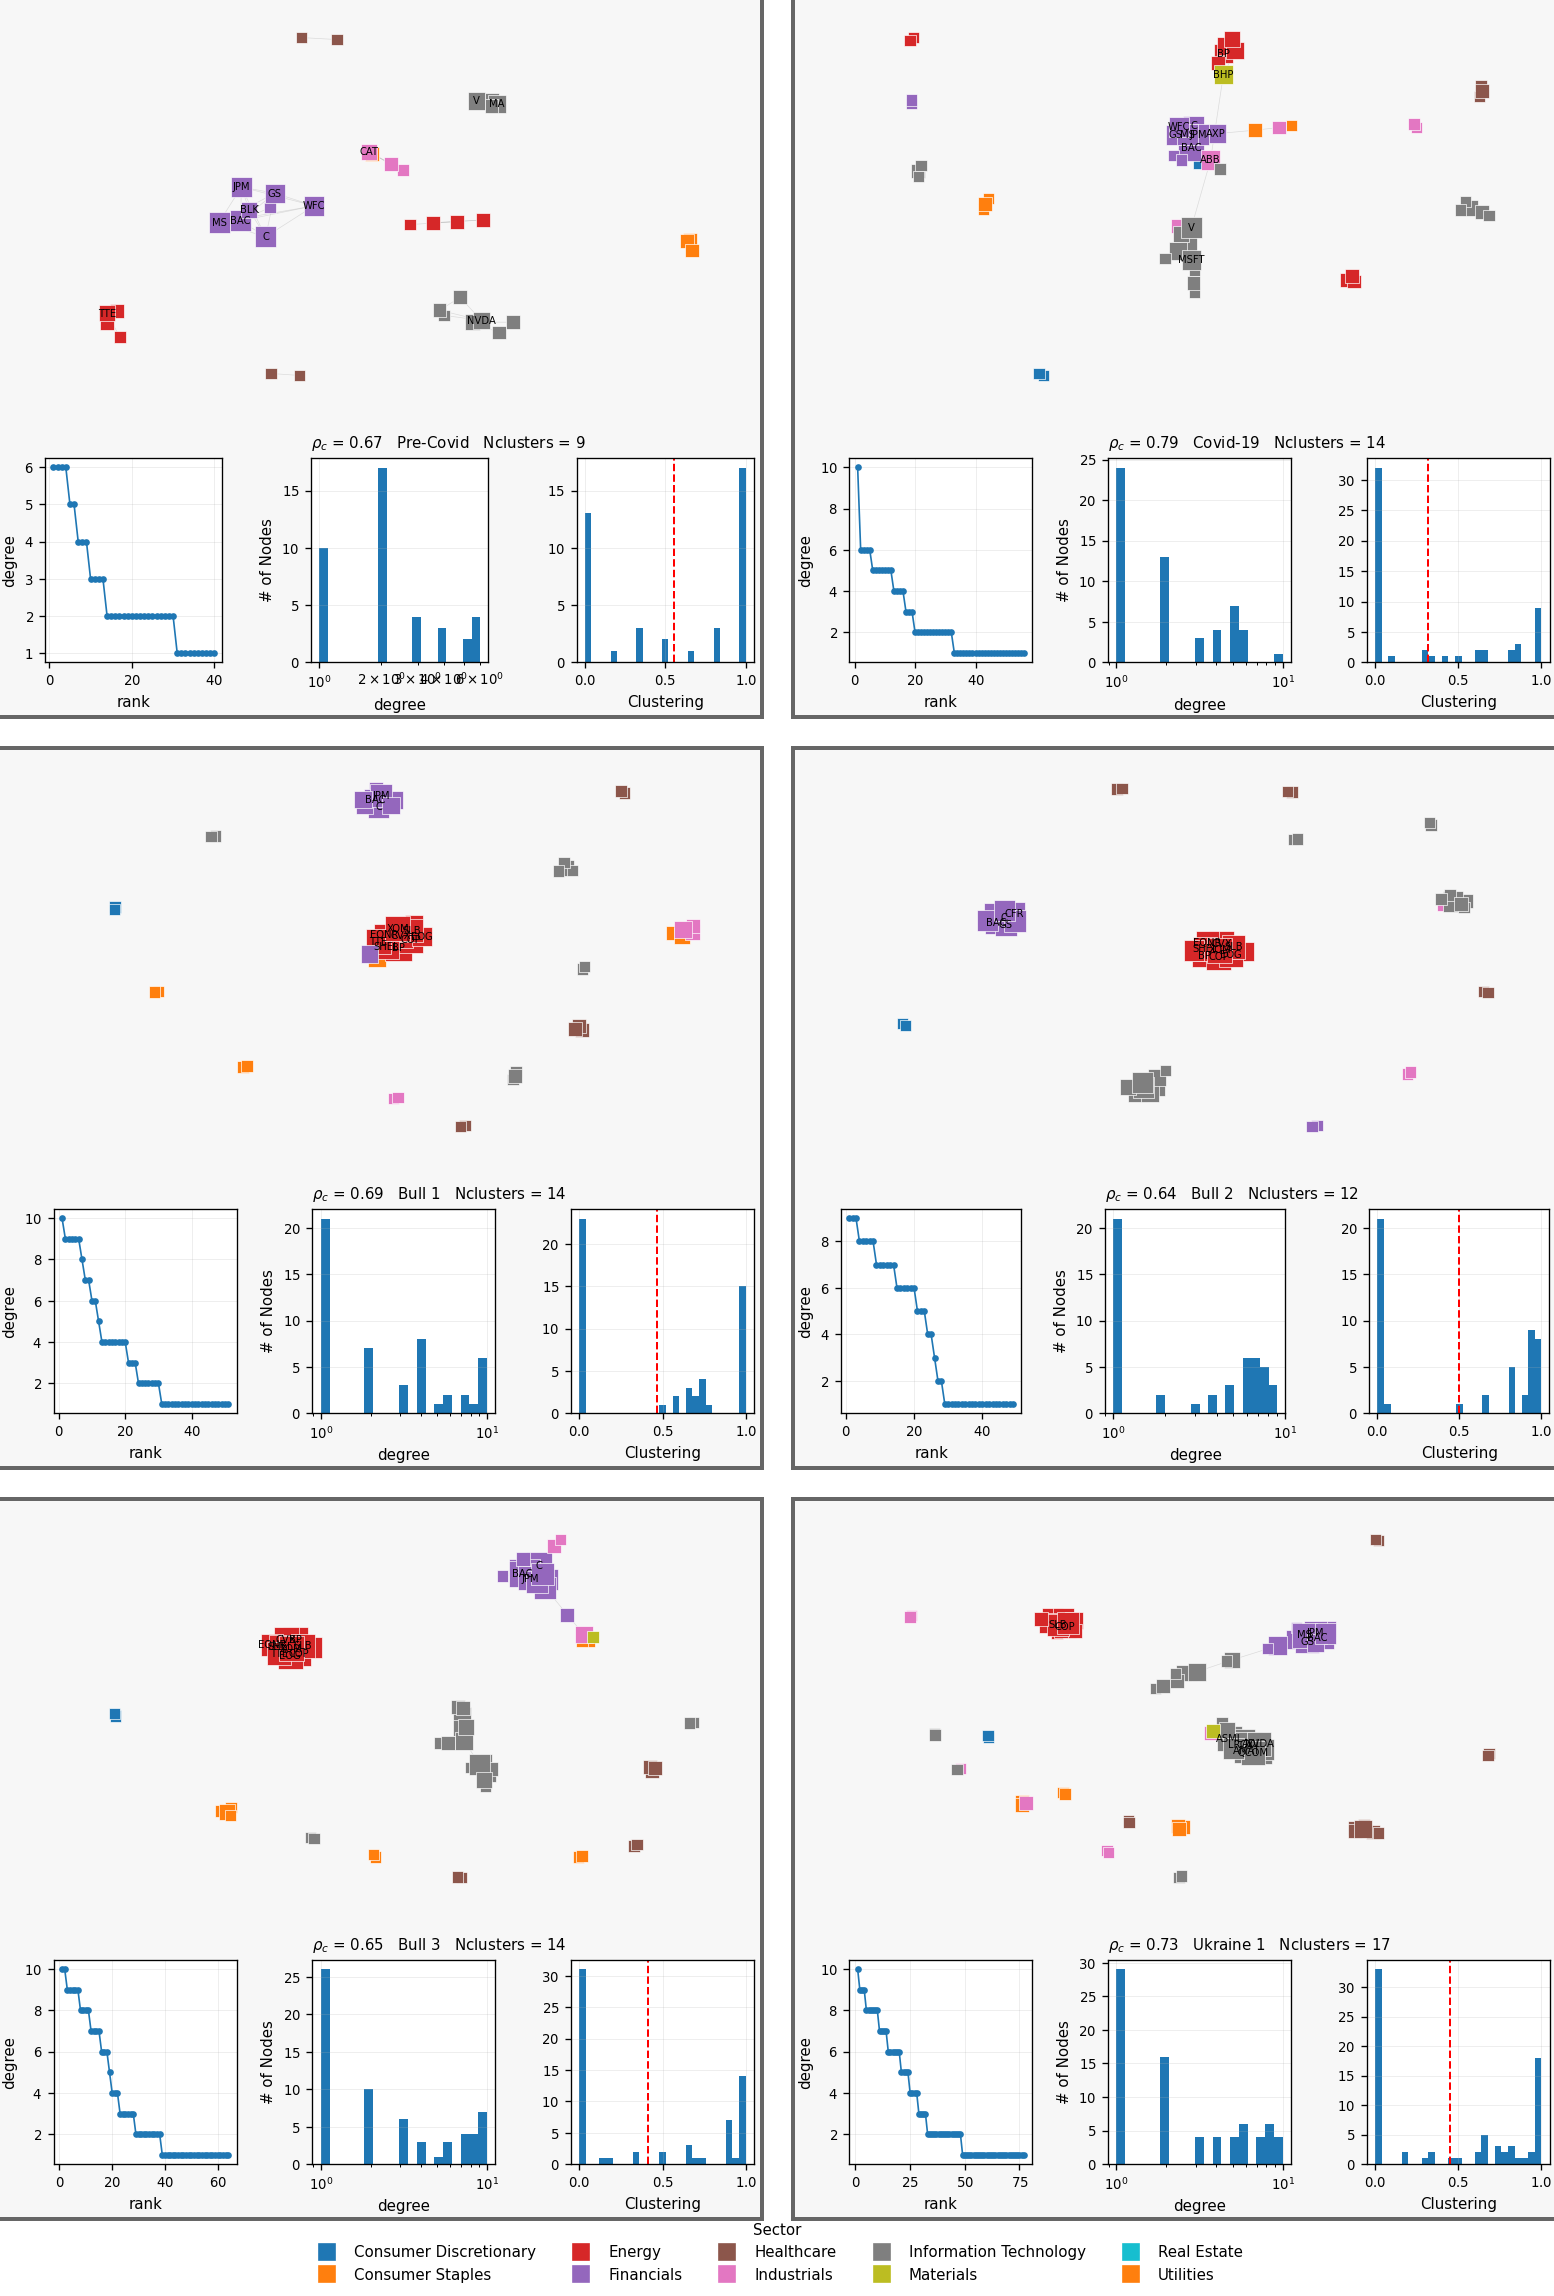

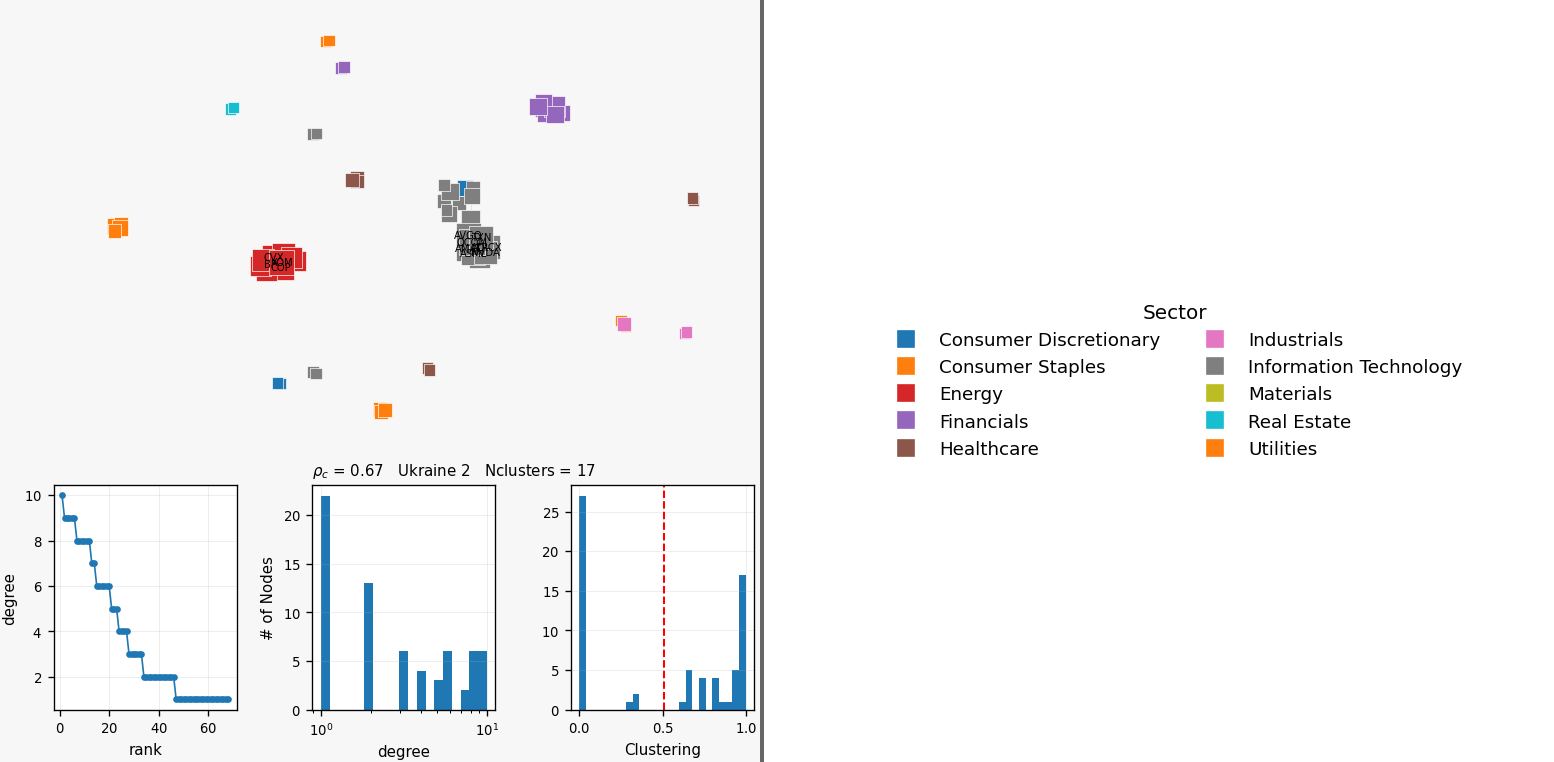

In [12]:
# --- Planche composite : réseau (haut) + 3 diagnostics (bas) par régime ---
def composite_board(periods_subset, fname, ncol=2):
    """Planche composite (réseau + degree-rank + 2 histogrammes) par régime.

    Parameters
    ----------
    periods_subset : list of (start, end, label)
        Sous-ensemble de régimes à tracer (un panneau chacun).
    fname : str
        Nom de fichier de sortie (sans extension) dans ``FIGDIR``.
    ncol : int
        Nombre de colonnes de panneaux.
    """
    nrow = int(np.ceil(len(periods_subset) / ncol))
    fig = plt.figure(figsize=(13, 6.4 * nrow), layout='constrained')
    subfigs = np.atleast_1d(
        fig.subfigures(nrow, ncol, wspace=0.04, hspace=0.04)).ravel()

    for sf, (start, end, label) in zip(subfigs, periods_subset):
        sf.set_facecolor('0.97')
        sf.patch.set(visible=True, edgecolor='0.4', linewidth=1.3)

        gs = sf.add_gridspec(2, 3, height_ratios=[2.0, 1.0])
        ax_net = sf.add_subplot(gs[0, :])              # réseau, pleine largeur
        ax_rank = sf.add_subplot(gs[1, 0])             # degree vs rank
        ax_deg = sf.add_subplot(gs[1, 1])              # # of nodes vs degree
        ax_clus = sf.add_subplot(gs[1, 2])             # clustering

        correlation_network(data, sectors, period=(start, end), seed=19,
                            label_top=12, ax=ax_net, title='', legend=False)
        degree_rank(data, period=(start, end), ax=ax_rank, color='tab:blue')
        network_distributions(data, period=(start, end), axes=(ax_deg, ax_clus),
                              period_label=label, suptitle=False)

    # légende des secteurs : dans la 1re case vide si elle existe, sinon en bas
    present = sorted(sectors.reindex(data.columns).dropna().unique())
    handles = [plt.Line2D([0], [0], marker='s', ls='', color=SECTOR_COLORS[s],
                          label=s, markersize=10) for s in present]
    empty = list(subfigs[len(periods_subset):])
    if empty:
        lax = empty[0].add_subplot(1, 1, 1)
        lax.axis('off')
        lax.legend(handles=handles, loc='center', ncol=2, frameon=False,
                   fontsize=11, title='Sector', title_fontsize=12)
        for sf in empty[1:]:
            sf.set_facecolor('none')
    else:
        fig.legend(handles=handles, loc='outside lower center', ncol=5,
                   frameon=False, fontsize=9, title='Sector')

    fig.savefig(f'{FIGDIR}/{fname}.pdf')
    fig.savefig(f'{FIGDIR}/{fname}.png')
    plt.show()


# planche 1 : 6 premiers régimes (3 x 2) ; planche 2 : le reste + légende
composite_board(periods[:6], 'fig_composite_mosaic_1')
composite_board(periods[6:], 'fig_composite_mosaic_2')